In [2]:
import os 
os.getcwd()

# never urn this on laptop

'/content'

# imports

In [3]:
# basiv imports 

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd 

# metrics 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

# Extraxt data

In [4]:
import yfinance as yf

stock = yf.download("^NSEI",start='2010-01-01')
df = stock['Close']
#df

# "^NSEI", start='2023-01-01') # tart="2010-01-01"

[*********************100%***********************]  1 of 1 completed


In [5]:
df.head()

Ticker,^NSEI
Date,
2010-01-04,5232.200195
2010-01-05,5277.899902
2010-01-06,5281.799805
2010-01-07,5263.100098
2010-01-08,5244.750000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4051 entries, 2010-01-04 to 2026-07-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^NSEI   4051 non-null   float64
dtypes: float64(1)
memory usage: 63.3 KB


In [7]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

# index to datetime

In [8]:
# index to datetime
df.index =pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

# df to series 

In [9]:
# df to series 
df=df.squeeze()
type(df)

pandas.core.series.Series

# object to numreic

In [10]:
# object to numreic
df = pd.to_numeric(df, errors="coerce")# replce wiwth nan
df.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 4051 entries, 2010-01-04 to 2026-07-03
Series name: ^NSEI
Non-Null Count  Dtype  
--------------  -----  
4051 non-null   float64
dtypes: float64(1)
memory usage: 63.3 KB


In [11]:
type(df)

pandas.core.series.Series

In [12]:
df.shape

(4051,)

In [13]:
df.isna().sum()

np.int64(0)

In [14]:
df.duplicated().sum()

np.int64(40)

# groupby

In [15]:
df.groupby(df.index.year).size().mean()

np.float64(238.2941176470588)

In [16]:
df.index[0],df.index[-1]

(Timestamp('2010-01-04 00:00:00'), Timestamp('2026-07-03 00:00:00'))

In [17]:
len(df.groupby(df.index.year))

17

In [18]:
df.describe()

,^NSEI
count,4051.000000
mean,12216.097885
std,6501.991470
min,4544.200195
25%,6305.600098
50%,10312.400391
75%,17394.799805
max,26328.550781


In [19]:
df.median()

10312.400390625

In [20]:
df.std()

6501.9914704392595

# cagr

In [21]:
begin=df.iloc[0]
end=df.iloc[-1]
years=(df.index[-1]-df.index[0]).days/365.25

cagr = (end/begin)**(1/years) - 1
cagr

np.float64(0.09750249464807714)

# Biggest one-day gain

In [22]:
# Biggest one-day gain 

daily_returns=df.pct_change().dropna()
print(daily_returns.sort_values(ascending=True))

Date
2020-03-23   -0.129805
2020-03-12   -0.083019
2020-03-16   -0.076121
2024-06-04   -0.059294
2015-08-24   -0.059151
                ...   
2021-02-01    0.047424
2019-09-20    0.053191
2020-03-20    0.058329
2020-03-25    0.066247
2020-04-07    0.087632
Name: ^NSEI, Length: 4050, dtype: float64


In [23]:
daily_returns.idxmax()

Timestamp('2020-04-07 00:00:00')

In [24]:
df_diff=df.diff(1).dropna()
print(df_diff.sort_values(ascending=True))

Date
2024-06-04   -1379.400391
2020-03-23   -1135.200195
2020-03-12    -868.250000
2022-02-24    -815.299805
2026-03-19    -775.650391
                 ...     
2020-04-07     708.400391
2024-06-03     733.201172
2024-06-05     735.849609
2026-04-08     873.699219
2025-05-12     916.699219
Name: ^NSEI, Length: 4050, dtype: float64


# daily average returns  

In [25]:
# daily average returns  
daily_returns.mean()

np.float64(0.00043326525979076253)

# daily volatility 

In [26]:
# daily volatility 
daily_volatility = daily_returns.std()
daily_volatility

0.010398376392442447

# annual volatility 

In [27]:
# annual volatility ______________-mistake )________
yearly_returns=df.groupby(df.index.year).mean()
yearly_returns.std()

6878.3214407389305

In [28]:
annual_volatility = daily_volatility * np.sqrt(252)
print(annual_volatility)

0.16506910783948617


# Trend Analysis

In [29]:
# 20 days moving average
# df_1=df.copy() # this is just another series no columns could be made
df_1=df.to_frame(name='price')
# or df_1['price'] = df.copy()
df_1['ma20']=df.rolling(20).mean()
df_1['ma50']=df.rolling(50).mean()
df_1['ma100']=df.rolling(100).mean()
df_1['ma200']=df.rolling(200).mean()

df_1.dropna(inplace=True)
df_1.head(2)

,price,ma20,ma50,ma100,ma200
Date,,,,,
2010-10-19,6027.299805,6085.899976,5781.032012,5538.086011,5322.798259
2010-10-20,5982.100098,6085.454980,5791.460010,5548.205010,5326.547759


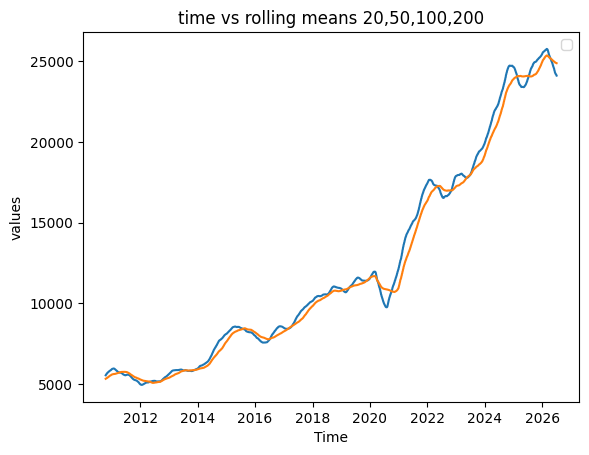

In [30]:
plt.plot(df_1.index,df_1['ma100'])
plt.plot(df_1.index,df_1['ma200'])
plt.xlabel('Time')
plt.ylabel('values')
plt.title('time vs rolling means 20,50,100,200')
plt.legend()
plt.show()

# Monthly performance


## 1. which calnder month is best 

In [63]:
daily_returns = stock['Close'].pct_change().dropna()
daily_returns

Ticker,^NSEI
Date,
2010-01-05,0.008734
2010-01-06,0.000739
2010-01-07,-0.003540
2010-01-08,-0.003487
2010-01-11,0.000887
...,...
2026-06-29,-0.004562
2026-06-30,-0.003362
2026-07-01,0.005870


In [70]:
# average returns each month returns  
monthly_avg_return=daily_returns.groupby(daily_returns.index.month).mean()

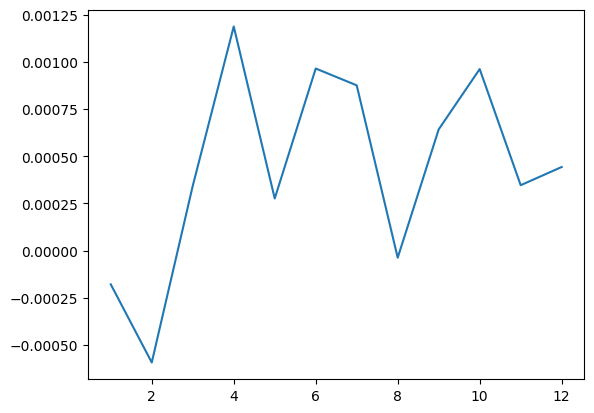

In [71]:
plt.plot(monthly_avg_return)

In [ ]:


# last day of each month is net month price
monthly_close = stock['Close'].resample('ME').last()

monthly_close.head(14)

Ticker,^NSEI
Date,
2010-01-31,4882.049805
2010-02-28,4922.299805
2010-03-31,5249.100098
2010-04-30,5278.000000
2010-05-31,5086.299805
2010-06-30,5312.500000
2010-07-31,5367.600098
2010-08-31,5402.399902
2010-09-30,6029.950195


In [ ]:
montly_returns = monthly_close.pct_change().dropna()
montly_returns.head(12)


Ticker,^NSEI
Date,
2010-02-28,0.008244
2010-03-31,0.066392
2010-04-30,0.005506
2010-05-31,-0.036321
2010-06-30,0.044472
2010-07-31,0.010372
2010-08-31,0.006483
2010-09-30,0.116161
2010-10-31,-0.002032


In [40]:
# group from all years 
# avg_of_all_years 

monthly_return_avg =montly_returns.groupby(montly_returns.index.month).mean()
monthly_return_avg

Ticker,^NSEI
Date,
1,0.000702
2,-0.011917
3,0.007873
4,0.022251
5,0.005262
6,0.020148
7,0.018436
8,-0.000902
9,0.013034


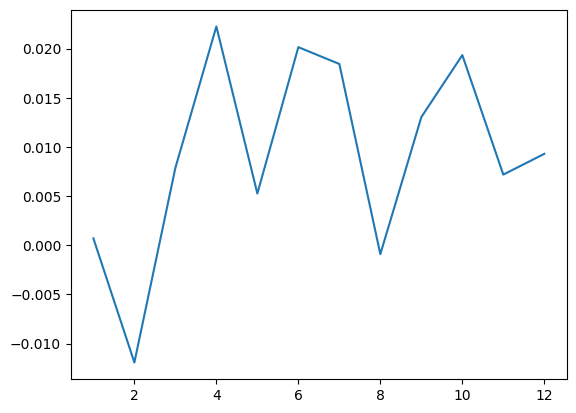

In [41]:
plt.plot(monthly_return_avg)

In [43]:
monthly_return_avg =montly_returns.groupby(montly_returns.index.month).agg(['mean','std','count'])
monthly_return_avg

Ticker     ^NSEI                
            mean       std count
Date                            
1       0.000702  0.052143    16
2      -0.011917  0.041099    17
3       0.007873  0.083143    17
4       0.022251  0.043426    17
5       0.005262  0.039198    17
6       0.020148  0.035348    17
7       0.018436  0.039519    17
8      -0.000902  0.042568    16
9       0.013034  0.044789    16
10      0.019338  0.044590    16
11      0.007189  0.049494    16
12      0.009300  0.036357    16

In [49]:
type(monthly_return_avg)
monthly_return_avg.columns

MultiIndex([('^NSEI',  'mean'),
            ('^NSEI',   'std'),
            ('^NSEI', 'count')],
           names=['Ticker', None])

In [51]:
monthly_return_avg.columns=['mean','std','count']
monthly_return_avg.columns

Index(['mean', 'std', 'count'], dtype='object')

Text(0.5, 0, 'months')

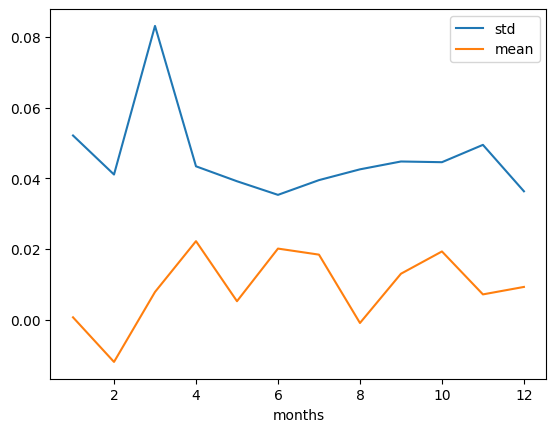

In [59]:
plt.plot(monthly_return_avg.index,monthly_return_avg['std'],label='std')
plt.plot(monthly_return_avg.index,monthly_return_avg['mean'],label='mean')
plt.legend()
plt.xlabel('months')

In [56]:
# plt.plot(monthly_return_avg.index,monthly_return_avg['count'])

# Yearly performance

In [ ]:
# table = | Year | Return % | Positive? |
# 
# last day return
yearly_close = stock['Close'].resample("YE").last()
yearly_close

Ticker,^NSEI
Date,
2010-12-31,6134.500000
2011-12-31,4624.299805
2012-12-31,5905.100098
2013-12-31,6304.000000
2014-12-31,8282.700195
2015-12-31,7946.350098
2016-12-31,8185.799805
2017-12-31,10530.700195
2018-12-31,10862.549805


In [ ]:
yearly_returns=yearly_close.pct_change().dropna()
yearly_returns=

Ticker,^NSEI
Date,
2011-12-31,-0.246181
2012-12-31,0.276972
2013-12-31,0.067552
2014-12-31,0.313880
2015-12-31,-0.040609
2016-12-31,0.030133
2017-12-31,0.286460
2018-12-31,0.031513
2019-12-31,0.120220


In [85]:
yearly_returns = yearly_returns.squeeze()
type(yearly_returns)


pandas.core.series.Series

In [87]:
table=pd.DataFrame()
table.index=yearly_returns.index
table['Return%']=yearly_returns*100

table['Positive?']=yearly_returns.gt(0).map({True:"YES",False:"NO"})
table


,Return%,Positive?
Date,,
2011-12-31,-24.618146,NO
2012-12-31,27.697172,YES
2013-12-31,6.755176,YES
2014-12-31,31.388011,YES
2015-12-31,-4.060875,NO
2016-12-31,3.013329,YES
2017-12-31,28.645953,YES
2018-12-31,3.151259,YES
2019-12-31,12.022043,YES


# Dashboard

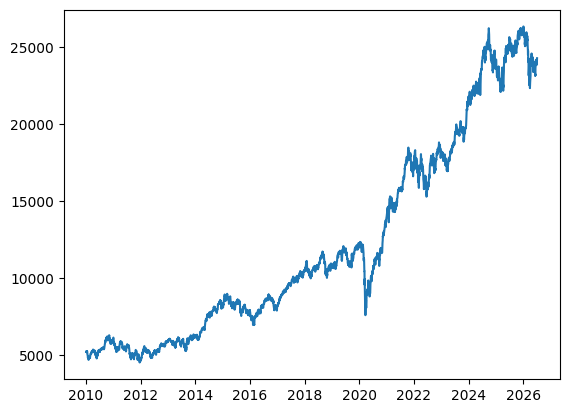

In [ ]:
plt.plot(stock.index,stock["Close"])
plt.title("Price Chart")

Text(0.5, 1.0, 'Daily Returns')

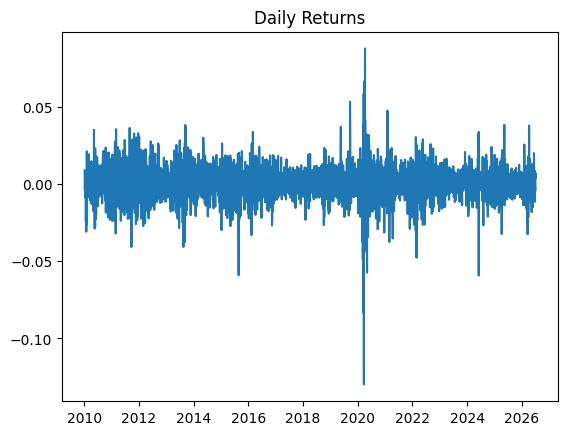

In [93]:
plt.plot(daily_returns)
plt.title("Daily Returns")

Text(0.5, 1.0, 'Rolling Volatility')

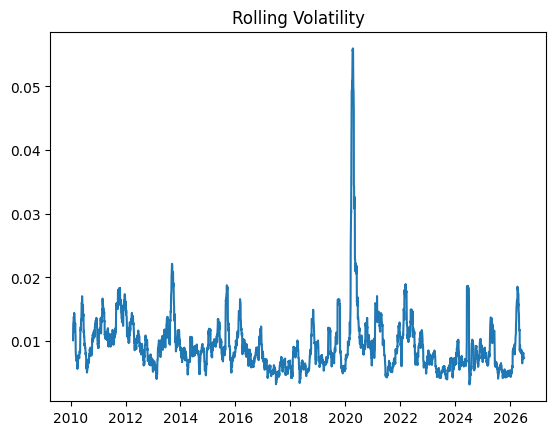

In [94]:
plt.plot(daily_returns.rolling(20).std())
plt.title("Rolling Volatility")

# Draw Down Analysis 
## not done